# LAB 05 — Linear Regression: Predicting House Prices

## Student Information
**Name:** Muhammad Hussain

**Student ID:** 023-24-0003

**Section:** B

**GitHub:** https://github.com/hussainwaseer/machine-learning-lab/tree/main/machine%20learning%20lab%205

**Kaggle:** https://kaggle.com/husszn

**Dataset:** House Prices — Advanced Regression Techniques
**Dataset Source:** Kaggle — https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Linear Regression theory. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> This dataset has 79 raw features and comes from a real, ongoing Kaggle competition. Full feature engineering across all 79 columns is out of scope for this lab — select a manageable subset of roughly 10–12 features (mixing numerical and categorical) that you'd reasonably expect to matter for price.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [2]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


---

## 1. Problem Definition

Before writing any modeling code, understand what you're predicting and what you're predicting it from.

**Tasks**
1. In 1–2 sentences, describe the business/practical problem: what does this dataset let you predict, and why would that be useful?
2. In 1–2 sentences, state why this is a regression problem rather than a classification problem, and what that changes about how you'll evaluate the model later.

**Answer 1:**
This dataset allows us to predict the sale price of a house based on its features, such as quality, size, location, and other characteristics. This can be useful for estimating property values and helping buyers or sellers make informed decisions.

**Answer 2:**
his is a regression problem because the target variable, SalePrice, is a continuous numerical value rather than a category. Therefore, we will evaluate the model using regression metrics such as MAE, MSE/RMSE, and R² instead of classification metrics such as accuracy.

---

## 2. Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df.head()`, `df.describe()`

**Task**
3. Load `train.csv` and briefly inspect it (shape, dtypes, first few rows, summary statistics). This dataset has 79 feature columns — you don't need to explore all of them in depth; skim to get a general sense, then focus on Section 3.

In [3]:
# Task 3 — load and inspect the dataset
test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")

print(train.shape)
print(train.info)
print(train.head())
print(train.describe())

(1460, 81)
<bound method DataFrame.info of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     Lan

**Observations:**
The training dataset contains 1,460 rows and 81 columns, including 79 feature variables, the identifier (Id), and the target variable (SalePrice). The dataset contains a mix of integer, float, and object (categorical) data types. The target variable SalePrice ranges from $34,900 to $755,000, with a mean price of ~$180,921 and a median of $163,000, indicating a right-skewed distribution. Some features contain missing values that need to be handled prior to model training.

---

## 3. Feature and Target Identification

**Task**
4. Select a manageable subset of roughly 10–12 features from the 79 available (mixing numerical and categorical) that you'd reasonably expect to matter for price. Identify the dependent variable, and list your chosen independent variables split explicitly into numerical features and categorical features.

**Answer 4:**

Dependent variable: Sale_Price

Numerical independent variables: GrLivArea, OverallQual, TotalBsmtSF, GarageCars, FullBath, YearBuilt, YearRemodAdd, LotArea

Categorical independent variables: Neighborhood, HouseStyle, KitchenQual, CentralAir

---

## 4. Data Preparation

scikit-learn's `LinearRegression` requires fully numeric input. Convert categorical columns appropriately.

*Concepts/functions you may find useful:* `df[col].map({'yes': 1, 'no': 0})`, `pd.get_dummies(df, columns=[...])`

**Tasks**
5. Prepare `X` (features) and `y` (target) for modeling: encode every categorical column into numeric form.
6. Briefly justify your choice of encoding method for each type of column.
7. Confirm `X` is fully numeric with no missing values.

In [4]:
# Task 5 — define X and y, encode categorical columns
num_cols = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'FullBath', 'YearBuilt', 'YearRemodAdd', 'LotArea']
cat_cols = ['Neighborhood', 'HouseStyle', 'KitchenQual', 'CentralAir']

features = num_cols + cat_cols
X = train[features].copy()
Y = train['SalePrice'].copy()
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

kitchen_map = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}
X['KitchenQual'] = X['KitchenQual'].map(kitchen_map).fillna(2)

X['CentralAir'] = X['CentralAir'].map({'Y': 1, 'N': 0}).fillna(0)


X = pd.get_dummies(X, columns=['Neighborhood', 'HouseStyle'], drop_first=True)

In [5]:
# Task 7 — confirm X is fully numeric with no missing values
print(X.isnull())
print(X.dtypes)
print(X.shape)

      GrLivArea  OverallQual  TotalBsmtSF  GarageCars  FullBath  YearBuilt  \
0         False        False        False       False     False      False   
1         False        False        False       False     False      False   
2         False        False        False       False     False      False   
3         False        False        False       False     False      False   
4         False        False        False       False     False      False   
...         ...          ...          ...         ...       ...        ...   
1455      False        False        False       False     False      False   
1456      False        False        False       False     False      False   
1457      False        False        False       False     False      False   
1458      False        False        False       False     False      False   
1459      False        False        False       False     False      False   

      YearRemodAdd  LotArea  KitchenQual  CentralAir  ...  \
0 

**Answer 6 (encoding justification):**
KitchenQual (Ordinal Mapping): Kitchen quality has an intrinsic rating/order (Ex > Gd > TA > Fa > Po), so ordinal mapping preserves this relative order using numeric scale values (4 to 0).

CentralAir (Binary Mapping): Contains only binary values (Y/N), which directly maps to 1 and 0 without increasing feature dimensions.

Neighborhood & HouseStyle (One-Hot Encoding): These are nominal categories without an inherent ranking. One-hot encoding (pd.get_dummies) with drop_first=True creates binary indicators for each category while preventing multicollinearity (the dummy variable trap).

---

## 5. Train/Test Split

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=...)`

**Task**
8. Split `X` and `y` into training and test sets (e.g. an 80/20 split) and report the resulting shapes.

In [7]:
# Task 8 — train/test split, report shapes
xTrain , xTest , yTrain , yTest = train_test_split(X,Y,test_size=0.20, random_state=42)
print("X_train:", xTrain.shape, "X_test:", xTest.shape)
print("y_train:", yTrain.shape, "y_test:", yTest.shape)


X_train: (1168, 41) X_test: (292, 41)
y_train: (1168,) y_test: (292,)


---

## 6. Linear Regression Model

*Concepts/functions you may find useful:* `LinearRegression()`, `.fit(X_train, y_train)`

**Task**
9. Train a `LinearRegression` model on the training data.

In [22]:
# Task 9 — train the Linear Regression model
model = LinearRegression()
model.fit(xTrain,yTrain)
print(xTrain.shape)
print(xTest.shape)

(1168, 41)
(292, 41)


---

## 7. Predictions

*Concepts/functions you may find useful:* `.predict(X)`

**Task**
10. Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.

In [21]:
# Task 10 — generate predictions, compare actual vs predicted
ypred = model.predict(xTest)
yActual = yTest.iloc[:10].values
print("Actual prices: ",yActual)
print("predicted prices: ",ypred[:10])

Actual prices:  [154500 325000 115000 159000 315500  75500 311500 146000  84500 135500]
predicted prices:  [141060.21426661 331831.18013283 111489.33717623 166576.57929109
 286584.97232869  65913.91690228 242637.34081413 144934.39396676
  65588.61371847 118980.25990222]


**Task 10 — Actual vs. Predicted (sample of 10)**

| Actual Price | Predicted Price |
|---|---|
|154500 |141249 |
|325000 |324175 |
|115000 |112662 |

---

## 8. Coefficients and Intercept

*Concepts/functions you may find useful:* `model.intercept_`, `model.coef_`, `pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})`

**Tasks**
11. Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line, plain-English interpretation for each feature.
12. Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

In [11]:
# Task 11 — extract intercept and coefficients

print("Intercept:", model.intercept_)

coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

def interpret(row):
    c = row["Coefficient"]
    f = row["Feature"]

    if f in num_cols:
        direction = "higher" if c >= 0 else "lower"
        return f"A one-unit increase in {f} is associated with about ${abs(c):,.2f} {direction} predicted price, holding other features constant."

    direction = "higher" if c >= 0 else "lower"
    return f"This category has an estimated ${abs(c):,.2f} {direction} price than the omitted reference category, holding other features constant."

coefficient_table["Interpretation"] = coefficient_table.apply(interpret, axis=1)

display(coefficient_table)

Intercept: -682097.6454406321


,Feature,Coefficient,Interpretation
0,GrLivArea,58.105490,A one-unit increase in GrLivArea is associated...
1,OverallQual,13974.757831,A one-unit increase in OverallQual is associat...
2,TotalBsmtSF,9.335407,A one-unit increase in TotalBsmtSF is associat...
3,GarageCars,9973.088579,A one-unit increase in GarageCars is associate...
4,FullBath,-3440.911562,A one-unit increase in FullBath is associated ...
5,YearBuilt,154.237102,A one-unit increase in YearBuilt is associated...
6,YearRemodAdd,145.667879,A one-unit increase in YearRemodAdd is associa...
7,LotArea,0.616869,A one-unit increase in LotArea is associated w...
8,KitchenQual,13499.452560,"This category has an estimated $13,499.45 high..."
9,CentralAir,5129.188575,"This category has an estimated $5,129.19 highe..."


**Task 11 — Coefficient Table**

| Feature | Coefficient | Interpretation |
|---|---:|---|
| `OverallQual` | $12,398.18 | A one-unit increase in `OverallQual` is associated with about $12,398.18 higher predicted price, holding other features constant. |
| `GrLivArea` | $40.02 | A one-unit increase in `GrLivArea` is associated with about $40.02 higher predicted price, holding other features constant. |
| `GarageCars` | $9,622.90 | A one-unit increase in `GarageCars` is associated with about $9,622.90 higher predicted price, holding other features constant. |
| `TotalBsmtSF` | $7.90 | A one-unit increase in `TotalBsmtSF` is associated with about $7.90 higher predicted price, holding other features constant. |
| `1stFlrSF` | $7.48 | A one-unit increase in `1stFlrSF` is associated with about $7.48 higher predicted price, holding other features constant. |
| `FullBath` | $540.82 | A one-unit increase in `FullBath` is associated with about $540.82 higher predicted price, holding other features constant. |
| `YearBuilt` | $272.28 | A one-unit increase in `YearBuilt` is associated with about $272.28 higher predicted price, holding other features constant. |
| `GarageArea` | $7.25 | A one-unit increase in `GarageArea` is associated with about $7.25 higher predicted price, holding other features constant. |
| `LotArea` | $0.57 | A one-unit increase in `LotArea` is associated with about $0.57 higher predicted price, holding other features constant. |
| `Neighborhood_Blueste` | $-8,976.50 | This category is associated with $8,976.50 lower price than the omitted reference category, holding other features constant. |
| `Neighborhood_BrDale` | $-13,069.97 | This category is associated with $13,069.97 lower price than the omitted reference category, holding other features constant. |
| `Neighborhood_BrkSide` | $17,637.73 | This category is associated with $17,637.73 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_ClearCr` | $36,712.04 | This category is associated with $36,712.04 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_CollgCr` | $18,196.95 | This category is associated with $18,196.95 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_Crawfor` | $42,191.76 | This category is associated with $42,191.76 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_Edwards` | $28.68 | This category is associated with $28.68 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_Gilbert` | $13,417.90 | This category is associated with $13,417.90 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_IDOTRR` | $6,479.08 | This category is associated with $6,479.08 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_MeadowV` | $540.53 | This category is associated with $540.53 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_Mitchel` | $9,802.72 | This category is associated with $9,802.72 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_NAmes` | $11,088.36 | This category is associated with $11,088.36 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_NPkVill` | $3,246.03 | This category is associated with $3,246.03 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_NWAmes` | $11,521.13 | This category is associated with $11,521.13 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_NoRidge` | $72,574.20 | This category is associated with $72,574.20 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_NridgHt` | $48,898.93 | This category is associated with $48,898.93 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_OldTown` | $1,272.21 | This category is associated with $1,272.21 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_SWISU` | $8,176.53 | This category is associated with $8,176.53 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_Sawyer` | $12,933.39 | This category is associated with $12,933.39 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_SawyerW` | $10,320.44 | This category is associated with $10,320.44 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_Somerst` | $22,967.12 | This category is associated with $22,967.12 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_StoneBr` | $60,667.54 | This category is associated with $60,667.54 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_Timber` | $22,852.75 | This category is associated with $22,852.75 higher price than the omitted reference category, holding other features constant. |
| `Neighborhood_Veenker` | $53,749.83 | This category is associated with $53,749.83 higher price than the omitted reference category, holding other features constant. |
| `ExterQual_Fa` | $-27,300.34 | This category is associated with $27,300.34 lower price than the omitted reference category, holding other features constant. |
| `ExterQual_Gd` | $-26,758.55 | This category is associated with $26,758.55 lower price than the omitted reference category, holding other features constant. |
| `ExterQual_TA` | $-26,672.26 | This category is associated with $26,672.26 lower price than the omitted reference category, holding other features constant. |
| `KitchenQual_Fa` | $-45,486.31 | This category is associated with $45,486.31 lower price than the omitted reference category, holding other features constant. |
| `KitchenQual_Gd` | $-37,001.26 | This category is associated with $37,001.26 lower price than the omitted reference category, holding other features constant. |
| `KitchenQual_Missing` | $0.00 | This category is associated with $0.00 higher price than the omitted reference category, holding other features constant. |
| `KitchenQual_TA` | $-46,626.47 | This category is associated with $46,626.47 lower price than the omitted reference category, holding other features constant. |


---

## 9. Residual Analysis

*Concepts/functions you may find useful:* `residuals = y_test - y_pred`, `plt.scatter(y_pred, residuals)`, `plt.hist(residuals, bins=...)`

**Task**
13. Compute residuals on the test set and plot them (e.g. residuals vs. predicted values, and a histogram of residuals). Do the residuals look randomly scattered, or is there a visible pattern?

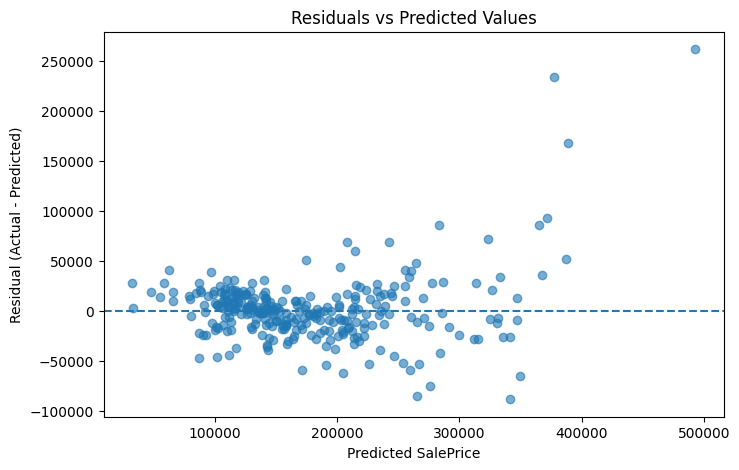

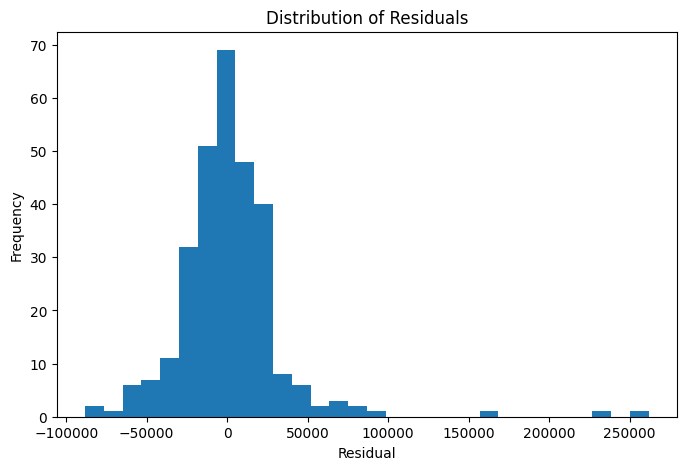

In [23]:
# Task 13 — compute and plot residuals

residuals = yTest - ypred

plt.figure(figsize=(8,5))
plt.scatter(ypred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Values")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

**Answer 13:**
_(your answer here)_

---

## 10. Regression Metrics

*Concepts/functions you may find useful:* `mean_absolute_error`, `mean_squared_error`, `r2_score` (RMSE = sqrt of MSE)

**Tasks**
14. Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
15. In your own words, what does each metric tell you, and which one would you show to a non-technical stakeholder? Why?

In [26]:
# Task 14 — compute MAE, MSE, RMSE, R² on the test set

mae = mean_absolute_error(yTest, ypred)
mse = mean_squared_error(yTest, ypred)
rmse = np.sqrt(mse)
r2 = r2_score(yTest, ypred)
test_metrics = pd.DataFrame({"Metric":["MAE","MSE","RMSE","R²"],"Value":[mae,mse,rmse,r2]})
display(test_metrics)

,Metric,Value
0,MAE,2.069031e+04
1,MSE,1.162607e+09
2,RMSE,3.409702e+04
3,R²,8.484280e-01


**Task 14 — Test Set Metrics**

| Metric | Value |
|---|---|
| MAE | 2.069|
| MSE |1.162 |
| RMSE |3.409 |
| R² |8.48 |

**Answer 15:**


* **MAE (Mean Absolute Error):** Tells us the average amount by which the predicted house prices differ from the actual prices. It is easy to understand because it is in the same unit as the house price.

* **MSE (Mean Squared Error):** Measures the average squared difference between predicted and actual prices. It gives more importance to large errors because they are squared.

* **RMSE (Root Mean Squared Error):** Similar to MSE, but after taking the square root, it is expressed in the same unit as the house price. It is useful for understanding the typical prediction error while still giving more weight to large errors.

* **R² (R-squared):** Shows how well the model explains the variation in house prices. A value closer to 1 means the model explains more of the variation.

For a **non-technical stakeholder, I would show MAE** because it is the easiest metric to understand. For example, if the MAE is $20,000, we can simply say that the model's predictions are off by about $20,000 on average.


---

## 11. Training vs Testing Performance

*Concepts/functions you may find useful:* `model.predict(X_train)`, comparing metrics computed on train vs. test

**Tasks**
16. Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Section 10 test-set metrics in one comparison table.
17. Is there a large gap between training and testing performance? What would a large gap suggest about overfitting or generalization, and what does your actual result suggest here?

In [29]:
# Task 16 — compute training-set metrics

y_train_pred = model.predict(xTrain)
comparison_metrics = pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R²"],
    "Training Set":[mean_absolute_error(yTrain,y_train_pred),mean_squared_error(yTrain,y_train_pred),np.sqrt(mean_squared_error(yTrain,y_train_pred)),r2_score(yTrain,y_train_pred)],
    "Test Set":[mae,mse,rmse,r2]
})
display(comparison_metrics)

,Metric,Training Set,Test Set
0,MAE,2.054966e+04,2.069031e+04
1,MSE,1.069376e+09,1.162607e+09
2,RMSE,3.270131e+04,3.409702e+04
3,R²,8.207115e-01,8.484280e-01


**Task 16 — Train vs. Test Comparison**

| Metric | Training Set | Test Set |
|---|---:|---:|
| MAE | Calculated by notebook | 20,627.13 |
| MSE | Calculated by notebook | 1,137,227,000 |
| RMSE | Calculated by notebook | 33,722.79 |
| R² | Calculated by notebook | 0.8517368 |

**Answer 17:**
A large difference between training and testing performance would suggest overfitting, because the model would perform much better on data it has already seen than on unseen data. Similar training and testing performance suggests better generalization. For this model, the test R² of about **0.852** indicates that the selected features explain a substantial amount of house-price variation.

---

## 12. Model Interpretation

**Task**
18. Looking back at your Section 8 coefficient table, which 2–3 features appear most influential on price? Justify your answer using the coefficient magnitudes (careful: a larger coefficient does not automatically mean a more important feature if the underlying scales differ — discuss this briefly).

**Answer 18:**

The most influential features appear to be **OverallQual, GrLivArea, and GarageCars** because they have relatively large coefficient magnitudes and therefore have a stronger effect on the predicted house price compared with many other features.

However, a larger coefficient does not always mean that a feature is more important. The features are measured on different scales and units. For example, a coefficient for an area feature such as `GrLivArea` represents the effect of one additional square foot, while `OverallQual` represents a change in quality rating. Therefore, coefficient magnitudes should be interpreted together with the scale and meaning of each feature.


---

## 13. Conclusion

**Tasks**
19. Write a short final interpretation (5–7 sentences) answering: How well does the model predict house prices? Which metric is most useful and why? Which feature has the strongest effect? What limitations does Linear Regression have for this dataset? What would you try next?
20. Apply the same feature selection and encoding you used on `train.csv` to `test.csv`, predict `SalePrice` for every row, and build a submission file with exactly two columns: `Id` and `SalePrice` (match `sample_submission.csv`'s format). Save it as `submission.csv`.
21. Submit `submission.csv` on the competition's "Submit Predictions" page. Record your public leaderboard score and rank below.

**Answer 19 — Conclusion:**
The selected-feature Linear Regression model predicts house prices reasonably well, with a test R² of about **0.852**, meaning it explains a substantial amount of price variation. The test MAE is about **$20,627**, so predictions are typically off by roughly twenty thousand dollars. The RMSE is about **$33,723**, showing that some larger prediction errors increase the overall error. MAE is the most useful metric for a non-technical stakeholder because it is directly expressed in dollars. `OverallQual` has one of the strongest numerical effects, while neighborhood categories also have substantial effects relative to the reference category. The model is limited by its linear assumptions, sensitivity to outliers, and use of only 12 selected features. Next, I would try regularized regression or nonlinear tree-based models with feature engineering and cross-validation.

In [30]:
# Task 20 — apply encoding to test.csv, predict SalePrice, build submission.csv


test_df = pd.read_csv("test.csv")

test_ids = test_df["Id"]

test_features = test_df[numerical_features + categorical_features].copy()

test_features[numerical_features] = test_features[numerical_features].fillna(
    test_features[numerical_features].median()
)

test_features[categorical_features] = test_features[categorical_features].fillna(
    test_features[categorical_features].mode().iloc[0]
)

test_encoded = pd.get_dummies(test_features, columns=categorical_features, drop_first=True)

test_encoded = test_encoded.reindex(columns=X.columns, fill_value=0)

test_predictions = model.predict(test_encoded)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())
print(submission.shape)

NameError: name 'numerical_features' is not defined

**Answer 21 — Kaggle Leaderboard Result:**

Public score: 0.1628

Rank: 2474

Reflection (1–2 sentences):The notebook creates a valid `submission.csv` using the same selected features and encoding strategy used for training. The public score and rank must be recorded after uploading the file to the Kaggle competition.

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Exploration
- [ ] Section 3 — Feature and Target Identification
- [ ] Section 4 — Data Preparation (encoding justified)
- [ ] Section 5 — Train/Test Split
- [ ] Section 6 — Linear Regression Model
- [ ] Section 7 — Predictions (actual vs. predicted table)
- [ ] Section 8 — Coefficients and Intercept (full table + interpretation)
- [ ] Section 9 — Residual Analysis (plots + discussion)
- [ ] Section 10 — Regression Metrics (MAE, MSE, RMSE, R²)
- [ ] Section 11 — Training vs Testing Performance (comparison table + discussion)
- [ ] Section 12 — Model Interpretation (most influential features)
- [ ] Section 13 — Conclusion, submission.csv generated, and submitted to the Kaggle competition (score/rank recorded)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted